# Quantum Algorithms Simulator

In this project, we build a brute-force classical simulator for quantum circuits to simulate the Deutsch–Jozsa algorithm and related quantum computations.

In [1]:
import sys
sys.path.append("..")  
import quantum_algorithms as qa # customers package 
# standard numerics and linear algebra libraries
import numpy as np  
import numpy.linalg as LA
import scipy.linalg as sciLA
from scipy.optimize import minimize_scalar
# for making plots
import matplotlib.pyplot as plt

# sparse matrix functions
import scipy.sparse as sparse

# for interactive graphics
from ipywidgets import interactive, interact
from ipywidgets import FloatSlider

# avoid typing np.XY all the time
from numpy import (array, pi, cos, sin, ones, size, sqrt, real, mod, append, arange, exp)

%matplotlib inline

### The Deutsch-Jozsa algorithm

Implement the $U_f$ gate for a general black box (or oracle) function $f: \{0,1\}^n \rightarrow \{0,1\}$. We don't want to simulate the auxiliary qubit explicitly, so the action of the $U_f$ gate is an added phase $(-1)^{f(x)}$ on each basis state x. Let's be super clear on what we mean by this: The computational basis consists of $2^n$ states: $\{|00..0\rangle, |00..01\rangle.., |11..1\rangle  \}$. The bitstring $x$ that enters into the black box function is the binary array of length $n$ that describes the state of each qubit for a given basis state. We can also enumerate  the basis states with the integer numbers $x$ running from $0$ to $2^n-1$. Now the bitstring $x$ is simply the list of binary digits of the integer number $x$. This identification of the "index" of the basis state with the corresponding "state" of the qubits will also be crucial for the other quantum algorithms like the quantum Fourier transform.

The function `indToState()` provided below will be very helpful for building the $U_f$ gate. Make sure you understand what it does.

In [2]:
# Example how indToState works:
n = 3 # number of qubits
k = 4 # index of the state in the computational basis
example_string = qa.operators.indToState(n, k)
print(f'The {k}-th element of a {n}-quibit state corresponds to the binary string {example_string}')

The 4-th element of a 3-quibit state corresponds to the binary string [1 0 0]


Now implement the Deutsch-Jozsa algorithm and use it to detemine for which $n$ the black box function provided along with this problem set is constant and for which it is balanced!

Check the result "classically" (by just calling the black box function often enough). 

Don't look at the source code of the black box function! This will make the wave function of the universe collapse ;-)

In [3]:
qa.operators.deutschJosza(qa.black_box.blackbox, 4)

The function is balanced.
The ratio of ones to zeros (computed directly) is: 0.5


array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [4]:
qa.operators.deutschJosza(qa.black_box.blackbox, 5)

The function is constant.
The ratio of ones to zeros (computed directly) is: 1.0


array([-1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.])

In [5]:
# In order to understand the black box, one can also iterate for different n
for i in range(15):
    print("For n equal to", i)
    qa.operators.deutschJosza(qa.black_box.blackbox, i)

For n equal to 0
The function is constant.
The ratio of ones to zeros (computed directly) is: 0.0
For n equal to 1
The function is balanced.
The ratio of ones to zeros (computed directly) is: 0.5
For n equal to 2
The function is balanced.
The ratio of ones to zeros (computed directly) is: 0.5
For n equal to 3
The function is constant.
The ratio of ones to zeros (computed directly) is: 0.0
For n equal to 4
The function is balanced.
The ratio of ones to zeros (computed directly) is: 0.5
For n equal to 5
The function is constant.
The ratio of ones to zeros (computed directly) is: 1.0
For n equal to 6
The function is constant.
The ratio of ones to zeros (computed directly) is: 0.0
For n equal to 7
The function is balanced.
The ratio of ones to zeros (computed directly) is: 0.5
For n equal to 8
The function is balanced.
The ratio of ones to zeros (computed directly) is: 0.5
For n equal to 9
The function is constant.
The ratio of ones to zeros (computed directly) is: 0.0
For n equal to 10
Th

### Simulating Measurements

The missing element of our quantum computer simulator is the measurement step. In the case we considered above, the output state was always one of the states of the computational basis, i.e. a "classical state" (and not entangled), but in general we end up with superpositions and the outcome of a measurement is random. This randomness we also want to implement in our quantum computer simulator. To do so, we can calculate the probabilities of all basis states and then randomly choose one of these outcomes according to this distribution. Write a function that takes a state $|\psi\rangle$ (i.e. its coefficient vector in the computational basis) as input and outputs one of the computational basis states as the measurement result. You may find the functions `random.rand` and `cumsum` from numpy helpful. 

Test your function on some example states, for example you could create an equal superposition of all basis states by applying Hadamard gates to all qubits.

Apply an $R_x$ rotation to single qubit initially in state $|0\rangle$ using various angles between 0 and $\pi$ and simulate $z$-basis meaurements. Evaluate the expectation value of $Z$ from these measuremets. For what angle are the statistical fluctuations compared to the exact expextation value the largest? 

In [7]:
## Test doMeasurement
n = 4
psi = qa.operators.initRegister(n)

# Apply a Hadamard gate to all qubits
for i in range(n):
    psi = qa.operators.buildSparseGateSingle(n, i, qa.operators.H) @ psi

print("psi=", psi)
print("Some possible states after measurement (each would require a fresh copy of the state!):")
for _ in range(10):
   print("Some possible states after measurement (each would require a fresh copy of the state!):", qa.operators.doMeasurement(psi))

psi= [0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25
 0.25 0.25]
Some possible states after measurement (each would require a fresh copy of the state!):
Some possible states after measurement (each would require a fresh copy of the state!): [1 0 0 0]
Some possible states after measurement (each would require a fresh copy of the state!): [1 0 1 1]
Some possible states after measurement (each would require a fresh copy of the state!): [1 0 0 1]
Some possible states after measurement (each would require a fresh copy of the state!): [0 1 0 1]
Some possible states after measurement (each would require a fresh copy of the state!): [1 0 1 1]
Some possible states after measurement (each would require a fresh copy of the state!): [0 1 1 0]
Some possible states after measurement (each would require a fresh copy of the state!): [0 1 1 0]
Some possible states after measurement (each would require a fresh copy of the state!): [1 0 0 1]
Some possible states after measurement (

Note that $Z_{\text{exact}} = \langle \sigma_z \rangle$ can be directly computed on the rotated states (for different angles).
On the contrary, the extimation of the simulated result $Z_{\text{sim}}$ after the measurements requires multiple shots to extract the statistics. 
Since for the single-qubit case the outcome of the doMeasurement function is $[0]$ for spin up and $[1]$ for spin down, one can compute the probability by means of $1-2x$ where $x=0,1$.

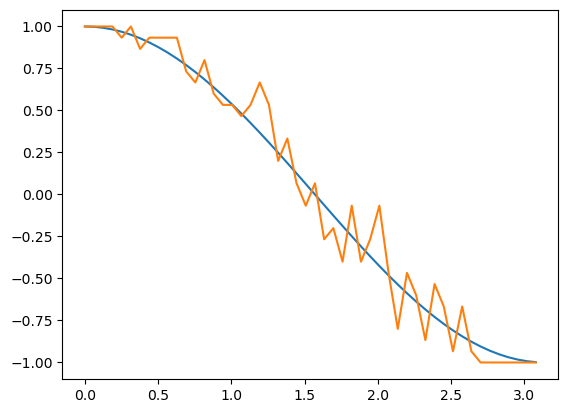

In [8]:
ini=array([1,0])
angle_grid=np.arange(0,pi,pi/50)
n_shots=30
states = [qa.operators.rotation([1,0,0],phi) @ ini for phi in angle_grid]
Z_exact=[]
Z_sim=[]

for state in states:
    cumZ_sim = 0
    for i in range(n_shots):
        cumZ_sim += 1-2*qa.operators.doMeasurement(state)[[0]]
    Z_exact.append(np.real(state.conj().T @ qa.operators.Z @ state))
    Z_sim.append(cumZ_sim/n_shots)
        
# One can compactify the previous "for" by writing:        
# Z_exact = [np.real(state.conj().T @ Z @ state) for state in states]
# Z_sim = [np.mean([1-2*doMeasurement(state)[[0]] for _ in range(n_shots) ]) for state in states] 

plt.plot(angle_grid,Z_exact)
plt.plot(angle_grid,Z_sim)

We can also compute the variance by considering the state $|\psi\rangle=\alpha |0\rangle + \sqrt{1-\alpha^{2}}|1\rangle$, where $\alpha$ can be related to the cosine of the previous angle.
In this way, $\langle \sigma_{z} \rangle = P_{0} - P_{1}$ and the variance is $\langle \sigma_{z}^{2} \rangle - \langle \sigma_{z} \rangle^{2} = 1 - (P_{0} - P_{1})^{2}$ where the probabilities are $P_{0}=|\alpha|^{2}$ and $P_{1}=1-|\alpha|^{2}$.
One can show that the peak in the variance corresponds to $\alpha=1/\sqrt{2}$.

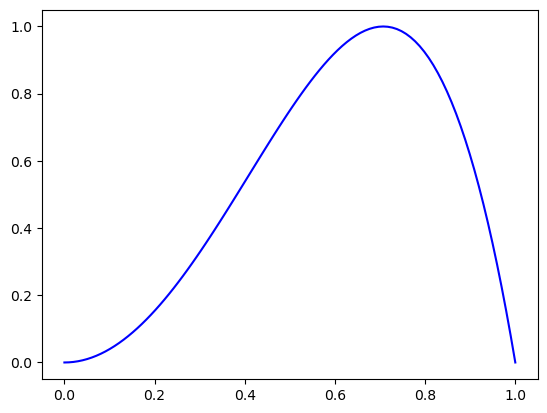

In [9]:
alpha = np.linspace(0, 1, 100)
plt.plot(alpha,qa.operators.varianceSigmaZ(alpha),color='blue')
plt.show()

In [10]:
# In order to compute the maximum, we use minimize_scalar, so we take -varianceSigmaZ
# Minimize the negative function over the interval [0, 1]
result = minimize_scalar(qa.operators.NegVarianceSigmaZ, bounds=(0, 1), method='bounded')

# Extract maximum x and f(x), correcting for the negation
x_max = result.x
f_max = -result.fun

print(f"Maximum value is {f_max} at x = {x_max}")

Maximum value is 0.9999999999999492 at x = 0.7071067014741756
